In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
from nicewebrl import data_analysis
from flax import serialization
import jax
import numpy as np
import craftax_experiment_structure as experiment
import craftax_experiment_configs as configs

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.
default_params
EnvParams(max_timesteps=200, day_length=100000, always_diamond=False, mob_despawn_distance=100000, max_attribute=5, god_mode=False, world_seeds=(0,), current_goal=0, start_positions=Array([[24, 24],
       [24, 24],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0]], dtype=int32), goal_locations=((-1, -1),), placed_goals=(-1,), fractal_noise_angles=(None, None, None, None), active_goals=Array([1., 1., 1.], dtype=float32), num_success=5)
Compiling environment reset and step functions.
	reset time: 11.886916160583496
	step time: 15.134279012680054
Compiling multi-render function.
	time: 3.391226053237915


In [5]:
!ls 'craftax_data'

db.sqlite_name=exp_debug=1           joint.log
db.sqlite_name=exp_debug=1-shm       log_412071415.log
db.sqlite_name=exp_debug=1-wal       user=412071415_name=exp_debug=1.json


In [6]:
from nicewebrl.utils import read_all_records

file_path = "craftax_data/user=412071415_name=exp_debug=1.json"
data_dicts = await read_all_records(file_path)

In [7]:
example_timestep = experiment.jax_web_env.reset(
  jax.random.PRNGKey(0), experiment.dummy_params
)

In [9]:
jax.tree_map(lambda x: x.shape, timestep)

TimeStep(state=EnvState(map=(1, 48, 48), item_map=(1, 48, 48), mob_map=(1, 48, 48), light_map=(1, 48, 48), down_ladders=(9, 2), up_ladders=(9, 2), chests_opened=(1,), monsters_killed=(1,), player_position=(2,), player_level=(), player_direction=(), player_health=(), player_food=(), player_drink=(), player_energy=(), player_mana=(), is_sleeping=(), is_resting=(), player_recover=(), player_hunger=(), player_thirst=(), player_fatigue=(), player_recover_mana=(), player_xp=(), player_dexterity=(), player_strength=(), player_intelligence=(), inventory=Inventory(wood=(), stone=(), coal=(), iron=(), diamond=(), sapling=(), pickaxe=(), sword=(), bow=(), arrows=(), armour=(4,), torches=(), ruby=(), sapphire=(), potions=(6,), books=()), melee_mobs=Mobs(position=(1, 1, 2), health=(1, 1), mask=(1, 1), attack_cooldown=(1, 1), type_id=(1, 1)), passive_mobs=Mobs(position=(1, 10, 2), health=(1, 10), mask=(1, 10), attack_cooldown=(1, 10), type_id=(1, 10)), ranged_mobs=Mobs(position=(1, 1, 2), health=(1,

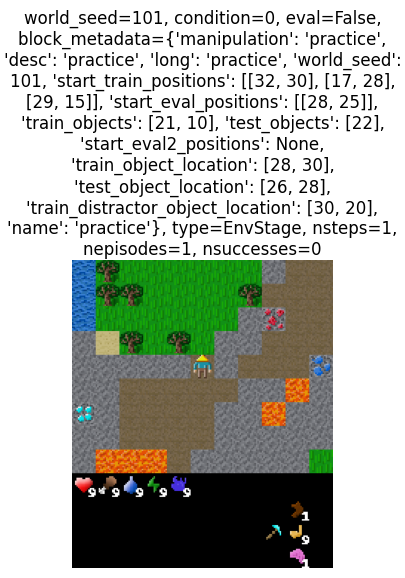

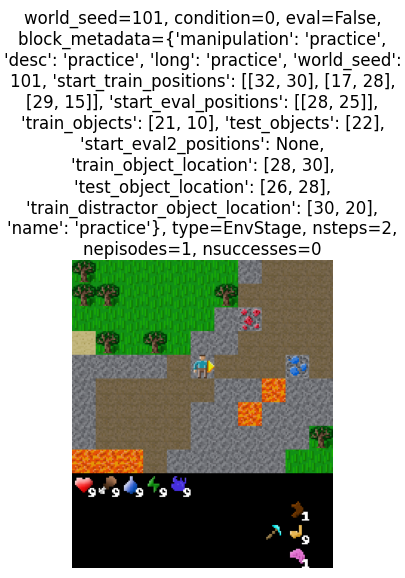

In [14]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from craftax.craftax.renderer import render_craftax_pixels


def dict_to_string(data):
  # Convert each key-value pair to "key=value" format
  pairs = [f"{key}={value}" for key, value in data.items()]

  # Join all pairs with ", " separator
  return ", ".join(pairs)


def render_fn(timestep):
  return render_craftax_pixels(timestep.state, block_pixel_size=16).astype(jnp.uint8)


# let's just print out the first few time-step to see what they look like
keys = set()
nidx = 2
# nidx = len(data_dicts)
for idx in range(nidx):
  datum = data_dicts[idx]
  # get the information describing block x stage pairs. you can edit this function if you want
  title = dict_to_string(datum["metadata"])
  timestep = datum["data"]["timestep"]
  timestep = serialization.from_bytes(example_timestep, timestep)

  image = render_fn(timestep)

  fig, ax = plt.subplots(1, 1, figsize=(4, 4))
  ax.imshow(image)
  ax.axis("off")
  ax.set_title(title, wrap=True)
  plt.show()

In [16]:
import nicewebrl

nicewebrl.get_size(timestep)

10261

In [17]:
nicewebrl.get_size(example_timestep)

285253